# Prediction Ranking for Control / Planning

Bu notebook, Trajectron++ çıktısını bir **kontrol algoritmasına** (MPC vb.) beslemek için
prediction ranking yapar.

### Senaryo
```
Drone kamerası → YOLO (detection) → Trajectron++ (prediction) → [BU NOTEBOOK: Ranking] → MPC (planning)
```

### Kontrol İçin 3 Ranking Kriteri

| Ranking | Soru | MPC'de Kullanımı |
|---------|------|------------------|
| **1. Nominal** | Yaya büyük ihtimalle nereye gidecek? | Referans/beklenen yol |
| **2. Risk (Safety)** | En tehlikeli senaryo ne? | Güvenlik kısıtı / collision avoidance |
| **3. Diverse Set** | Farklı olasılıkları temsil eden K trajektori? | Scenario-based robust MPC |

### Genel amaçlı ranking vs kontrol ranking farkı
- Genel: "En olası trajektori hangisi?" → Tek cevap
- Kontrol: "Planlayıcıya ne vermem lazım?" → Nominal + worst-case + diverse set

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / "Trajectron-plus-plus"
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "trajectron"))

import dill
import json
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import ConvexHull

from environment import Environment
from utils import prediction_output_to_trajectories
from model.model_registrar import ModelRegistrar
from model.online.online_trajectron import OnlineTrajectron

print("Imports OK")

Imports OK


In [3]:
# ===== VERİ ve MODEL =====
PROCESSED_DIR = PROJECT_ROOT / "experiments" / "processed"
with open(PROCESSED_DIR / "my_video_test_scaled.pkl", "rb") as f:
    eval_env = dill.load(f)

MODEL_DIR = PROJECT_ROOT / "experiments" / "pedestrians" / "models" / \
            "models_26_Dec_2025_14_50_24_eth_demo"
CHECKPOINT = 3

with open(MODEL_DIR / "config.json", "r") as f:
    hyperparams = json.load(f)
hyperparams["incl_robot_node"] = False
hyperparams["offline_scene_graph"] = True

model_registrar = ModelRegistrar(MODEL_DIR, device="cpu")
model_registrar.load_models(iter_num=CHECKPOINT)
online_traj = OnlineTrajectron(model_registrar, hyperparams, device="cpu")
print("Model ready")


Loading from /Users/simayyalcin/Trajectron-plus-plus/experiments/pedestrians/models/models_26_Dec_2025_14_50_24_eth_demo/model_registrar-3.pt
Loaded!

Model ready


/Users/simayyalcin/Trajectron-plus-plus/trajectron/model/model_registrar.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model_dict = torch.load(save_path, map_loc

In [4]:
# ===== PREDICTION =====
NUM_SAMPLES = 20

scene = eval_env.scenes[0]
max_hl = hyperparams["maximum_history_length"]
ph = hyperparams["prediction_horizon"]

latest_timestep = scene.timesteps - ph - 1
timestep = max_hl if max_hl <= latest_timestep else max(1, latest_timestep)

env = Environment(
    node_type_list=eval_env.node_type_list,
    standardization=eval_env.standardization,
    scenes=[scene],
    attention_radius=eval_env.attention_radius,
    robot_type=eval_env.robot_type
)
online_traj.set_environment(env, timestep)
input_dict = scene.get_clipped_input_dict(timestep, hyperparams["state"])

dists, preds = online_traj.incremental_forward(
    input_dict, maps=None,
    prediction_horizon=ph,
    num_samples=NUM_SAMPLES,
    full_dist=True
)

pred_dict, hist_dict, fut_dict = prediction_output_to_trajectories(
    {timestep: preds}, scene.dt, max_hl, ph, map=None
)
prediction_dict = pred_dict[timestep]
histories_dict = hist_dict[timestep]

print(f"timestep={timestep}, ph={ph}, num_samples={NUM_SAMPLES}")
for node in prediction_dict:
    p = prediction_dict[node]
    h = histories_dict[node]
    print(f"  {node}: preds {p.shape}, history {h.shape}")

timestep=7, ph=12, num_samples=20
  PEDESTRIAN/0: preds (1, 20, 12, 2), history (7, 2)


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(


In [5]:
# ===== ROBOT YOLU TANIMLA =====
# Gerçek uygulamada bu MPC'den veya path planner'dan gelir.
# Şimdilik basit bir düz çizgi veya elle tanımlı yol kullanıyoruz.
#
# Koordinatlar scaled (x100) image coordinates:
#   x ∈ [0, 100] (sol→sağ)
#   y ∈ [0, 100] (yukarı→aşağı, image coords)

# Yayaların mevcut pozisyonuna bakalım
for node in histories_dict:
    h = histories_dict[node]
    print(f"{node} current pos: ({h[-1, 0]:.1f}, {h[-1, 1]:.1f})")
    p = prediction_dict[node][0]  # (N, ph, 2)
    print(f"  Pred endpoint range: x=[{p[:,-1,0].min():.1f}, {p[:,-1,0].max():.1f}], "
          f"y=[{p[:,-1,1].min():.1f}, {p[:,-1,1].max():.1f}]")

# Robot yolu: ph timestep boyunca sabit hızla giden düz çizgi
# Bu değerleri kendi senaryonuza göre değiştirin!
robot_start = np.array([50.0, 70.0])  # başlangıç
robot_end   = np.array([70.0, 70.0])  # bitiş (ph adım sonra)
robot_path  = np.linspace(robot_start, robot_end, ph)  # (ph, 2)

print(f"\nRobot path: {robot_start} → {robot_end}, {ph} steps")

PEDESTRIAN/0 current pos: (34.4, 62.2)
  Pred endpoint range: x=[34.0, 34.2], y=[62.7, 62.8]

Robot path: [50. 70.] → [70. 70.], 12 steps


In [6]:
# ===== RANKING FONKSİYONLARI (KONTROL İÇİN) =====

def rank_nominal(predictions):
    """
    NOMINAL RANKING: MPC'nin 'beklenen senaryo' olarak kullanacağı trajektori.
    
    Yöntem: Pairwise distance — diğer tüm sample'lara en yakın
    olan trajektori en 'temsili' olandır.
    
    MPC kullanımı: x_ref (reference trajectory) olarak verilir.
    """
    samples = predictions[0]  # (N, ph, 2)
    N = samples.shape[0]
    avg_dists = np.zeros(N)
    
    for i in range(N):
        total = 0.0
        for j in range(N):
            if i != j:
                d = np.sqrt(((samples[i] - samples[j]) ** 2).sum(axis=1)).mean()
                total += d
        avg_dists[i] = total / (N - 1)
    
    order = np.argsort(avg_dists)
    return {
        "order": order,
        "scores": -avg_dists,
        "best_traj": samples[order[0]],
        "mean_traj": samples.mean(axis=0),
    }


def rank_risk(predictions, robot_path):
    """
    RISK RANKING: Robot yoluna en yakın geçen (en tehlikeli) trajektori.
    
    Her timestep'te yaya-robot mesafesinin minimumunu hesaplar.
    En küçük minimum mesafe = en tehlikeli = Rank 1.
    
    MPC kullanımı: Safety constraint olarak kullanılır.
    'Bu trajektori gerçekleşirse minimum X mesafe bırakmalıyım.'
    """
    samples = predictions[0]  # (N, ph, 2)
    N = samples.shape[0]
    ph_len = min(samples.shape[1], robot_path.shape[0])
    
    min_distances = []  # her sample için robot'a en yakın mesafe
    avg_distances = []  # her sample için ortalama mesafe
    
    for s in range(N):
        dists_per_t = []
        for t in range(ph_len):
            d = np.sqrt(((samples[s, t] - robot_path[t]) ** 2).sum())
            dists_per_t.append(d)
        min_distances.append(min(dists_per_t))
        avg_distances.append(np.mean(dists_per_t))
    
    min_distances = np.array(min_distances)
    avg_distances = np.array(avg_distances)
    
    # En tehlikeli = en küçük mesafe = Rank 1
    order = np.argsort(min_distances)
    
    return {
        "order": order,
        "min_distances": min_distances,
        "avg_distances": avg_distances,
        "most_dangerous_traj": samples[order[0]],
        "safest_traj": samples[order[-1]],
    }


def select_diverse_set(predictions, K=5):
    """
    DIVERSE SET: K tane birbirinden farklı trajektori seç.
    
    Yöntem: Farthest Point Sampling (FPS)
    1. En 'nominal' trajektori ile başla
    2. Mevcut sete en uzak olanı ekle
    3. K'ya ulaşana kadar tekrarla
    
    MPC kullanımı: Scenario-based robust MPC.
    'Bu K farklı senaryonun hepsine karşı güvenli ol.'
    """
    samples = predictions[0]  # (N, ph, 2)
    N = samples.shape[0]
    K = min(K, N)
    
    # Pairwise distance matrix
    dist_matrix = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            d = np.sqrt(((samples[i] - samples[j]) ** 2).sum(axis=1)).mean()
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    
    # FPS: en nominal ile başla (en küçük toplam mesafe)
    total_dists = dist_matrix.sum(axis=1)
    selected = [np.argmin(total_dists)]
    
    for _ in range(K - 1):
        # Mevcut sete en uzak olanı bul
        min_dists_to_set = np.full(N, np.inf)
        for idx in selected:
            min_dists_to_set = np.minimum(min_dists_to_set, dist_matrix[idx])
        
        # Zaten seçilenleri hariç tut
        for idx in selected:
            min_dists_to_set[idx] = -1
        
        next_idx = np.argmax(min_dists_to_set)
        selected.append(next_idx)
    
    return {
        "selected_indices": selected,
        "selected_trajs": [samples[i] for i in selected],
        "dist_matrix": dist_matrix,
    }


def compute_prediction_envelope(predictions, percentile=90):
    """
    PREDICTION ENVELOPE: Öngörülerin kapladığı alanı hesapla.
    
    MPC kullanımı: Chance-constrained MPC.
    'Yaya %90 ihtimalle bu alan içinde olacak.'
    """
    samples = predictions[0]  # (N, ph, 2)
    N, ph_len, _ = samples.shape
    
    envelopes = []
    for t in range(ph_len):
        points = samples[:, t, :]  # (N, 2)
        center = points.mean(axis=0)
        dists = np.sqrt(((points - center) ** 2).sum(axis=1))
        radius = np.percentile(dists, percentile)
        envelopes.append({"center": center, "radius": radius, "points": points})
    
    return envelopes


print("Control ranking functions defined")

Control ranking functions defined


In [7]:
# ===== RANKLARI HESAPLA =====
for node in prediction_dict:
    p = prediction_dict[node]
    
    nominal  = rank_nominal(p)
    risk     = rank_risk(p, robot_path)
    diverse  = select_diverse_set(p, K=5)
    envelope = compute_prediction_envelope(p, percentile=90)
    
    print(f"\n{'='*60}")
    print(f"Node: {node}")
    print(f"{'='*60}")
    
    print(f"\n  NOMINAL (beklenen yol):")
    print(f"    Best sample: #{nominal['order'][0]}")
    print(f"    Endpoint: ({nominal['best_traj'][-1, 0]:.1f}, {nominal['best_traj'][-1, 1]:.1f})")
    
    print(f"\n  RISK (tehlike sırası):")
    r_order = risk['order']
    print(f"    Most dangerous: sample #{r_order[0]}, min dist to robot = {risk['min_distances'][r_order[0]]:.2f}")
    print(f"    Safest: sample #{r_order[-1]}, min dist to robot = {risk['min_distances'][r_order[-1]]:.2f}")
    
    print(f"\n  DIVERSE SET ({len(diverse['selected_indices'])} trajectories):")
    print(f"    Selected samples: {diverse['selected_indices']}")
    
    print(f"\n  ENVELOPE (90th percentile radius):")
    radii = [e['radius'] for e in envelope]
    print(f"    Radius over time: {[f'{r:.2f}' for r in radii]}")
    print(f"    Max radius: {max(radii):.2f} (t={np.argmax(radii)})")


Node: PEDESTRIAN/0

  NOMINAL (beklenen yol):
    Best sample: #1
    Endpoint: (34.1, 62.8)

  RISK (tehlike sırası):
    Most dangerous: sample #17, min dist to robot = 17.43
    Safest: sample #2, min dist to robot = 17.46

  DIVERSE SET (5 trajectories):
    Selected samples: [1, 18, 13, 6, 16]

  ENVELOPE (90th percentile radius):
    Radius over time: ['0.03', '0.03', '0.04', '0.05', '0.05', '0.06', '0.09', '0.08', '0.08', '0.08', '0.08', '0.10']
    Max radius: 0.10 (t=11)


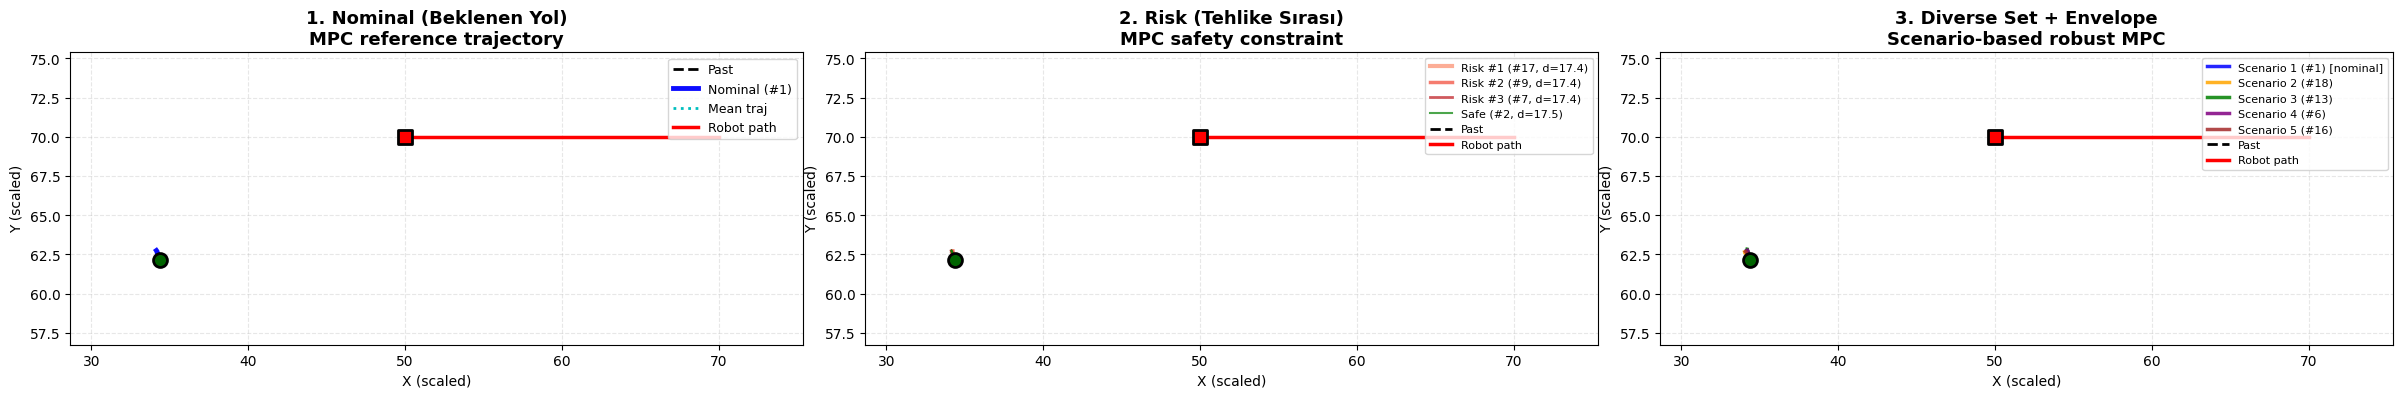

In [8]:
# ===== ANA GÖRSELLEŞTİRME: 3 Panel =====

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
cmap = plt.cm.viridis

for node in prediction_dict:
    history = histories_dict[node]
    predictions = prediction_dict[node]  # (1, N, ph, 2)
    samples = predictions[0]              # (N, ph, 2)
    N = samples.shape[0]
    
    if np.isnan(history[-1]).any():
        continue
    
    # ========== PANEL 1: NOMINAL ==========
    ax = axes[0]
    ax.set_title("1. Nominal (Beklenen Yol)\nMPC reference trajectory", fontsize=13, fontweight='bold')
    
    for s in range(N):
        ax.plot(samples[s, :, 0], samples[s, :, 1], color='lightgray', alpha=0.4, linewidth=0.8)
    
    ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=2, label='Past')
    ax.plot(nominal['best_traj'][:, 0], nominal['best_traj'][:, 1],
            'b-', linewidth=3.5, alpha=0.95, label=f'Nominal (#{nominal["order"][0]})', zorder=5)
    ax.plot(nominal['mean_traj'][:, 0], nominal['mean_traj'][:, 1],
            'c:', linewidth=2, label='Mean traj', zorder=4)
    ax.plot(robot_path[:, 0], robot_path[:, 1], 'r-', linewidth=2.5, label='Robot path', zorder=4)
    ax.scatter(history[-1, 0], history[-1, 1], s=100, c='darkgreen', edgecolors='black', linewidth=2, zorder=6)
    ax.scatter(robot_path[0, 0], robot_path[0, 1], s=100, c='red', edgecolors='black', marker='s', linewidth=2, zorder=6)
    ax.legend(fontsize=9, loc='upper right')
    
    # ========== PANEL 2: RISK ==========
    ax = axes[1]
    ax.set_title("2. Risk (Tehlike Sırası)\nMPC safety constraint", fontsize=13, fontweight='bold')
    
    r_order = risk['order']
    for rank_pos, s_idx in enumerate(r_order):
        if rank_pos < 3:  # top 3 tehlikeli
            color = plt.cm.Reds(0.4 + 0.2 * rank_pos)
            lw = 3.0 - rank_pos * 0.5
            label = f'Risk #{rank_pos+1} (#{s_idx}, d={risk["min_distances"][s_idx]:.1f})'
        elif rank_pos >= N - 2:  # en güvenli 2
            color = 'green'
            lw = 1.5
            label = f'Safe (#{s_idx}, d={risk["min_distances"][s_idx]:.1f})' if rank_pos == N-1 else None
        else:
            color = 'lightgray'
            lw = 0.6
            label = None
        ax.plot(samples[s_idx, :, 0], samples[s_idx, :, 1],
                color=color, linewidth=lw, alpha=0.7 if color != 'lightgray' else 0.3,
                label=label, zorder=3 if color != 'lightgray' else 1)
    
    ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=2, label='Past')
    ax.plot(robot_path[:, 0], robot_path[:, 1], 'r-', linewidth=2.5, label='Robot path', zorder=4)
    ax.scatter(history[-1, 0], history[-1, 1], s=100, c='darkgreen', edgecolors='black', linewidth=2, zorder=6)
    ax.scatter(robot_path[0, 0], robot_path[0, 1], s=100, c='red', edgecolors='black', marker='s', linewidth=2, zorder=6)
    ax.legend(fontsize=8, loc='upper right')
    
    # ========== PANEL 3: DIVERSE + ENVELOPE ==========
    ax = axes[2]
    ax.set_title("3. Diverse Set + Envelope\nScenario-based robust MPC", fontsize=13, fontweight='bold')
    
    for s in range(N):
        ax.plot(samples[s, :, 0], samples[s, :, 1], color='lightgray', alpha=0.25, linewidth=0.5)
    
    colors_div = ['blue', 'orange', 'green', 'purple', 'brown']
    for i, s_idx in enumerate(diverse['selected_indices']):
        c = colors_div[i % len(colors_div)]
        label = f'Scenario {i+1} (#{s_idx})'
        if i == 0:
            label += ' [nominal]'
        ax.plot(samples[s_idx, :, 0], samples[s_idx, :, 1],
                color=c, linewidth=2.5, alpha=0.85, label=label, zorder=4)
    
    # Envelope çiz
    for t_idx, env_t in enumerate(envelope):
        circle = plt.Circle(env_t['center'], env_t['radius'],
                           fill=True, facecolor='yellow', edgecolor='orange',
                           alpha=0.08 + 0.02 * t_idx, linewidth=0.5, zorder=0)
        ax.add_patch(circle)
    
    ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=2, label='Past')
    ax.plot(robot_path[:, 0], robot_path[:, 1], 'r-', linewidth=2.5, label='Robot path', zorder=4)
    ax.scatter(history[-1, 0], history[-1, 1], s=100, c='darkgreen', edgecolors='black', linewidth=2, zorder=6)
    ax.scatter(robot_path[0, 0], robot_path[0, 1], s=100, c='red', edgecolors='black', marker='s', linewidth=2, zorder=6)
    ax.legend(fontsize=8, loc='upper right')

# Tüm paneller için ortak axis ayarları
for ax in axes:
    all_pts = np.concatenate([history] + [samples[s] for s in range(N)] + [robot_path])
    mask = ~np.isnan(all_pts).any(axis=1)
    if mask.any():
        span = max(all_pts[mask, 0].ptp(), all_pts[mask, 1].ptp(), 1e-6)
        pad = 0.15 * span
        ax.set_xlim(all_pts[mask, 0].min() - pad, all_pts[mask, 0].max() + pad)
        ax.set_ylim(all_pts[mask, 1].min() - pad, all_pts[mask, 1].max() + pad)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel('X (scaled)')
    ax.set_ylabel('Y (scaled)')

plt.tight_layout()
plt.show()

In [9]:
# ===== MPC'YE VERİLECEK ÇIKTI =====
# Bu hücre, kontrol algoritmasına ne vermeniz gerektiğini özetler.

for node in prediction_dict:
    p = prediction_dict[node]
    samples = p[0]  # (N, ph, 2)
    
    print("="*60)
    print(f"MPC INPUT SUMMARY — {node}")
    print("="*60)
    
    # 1. Nominal trajectory (reference)
    nom_traj = nominal['best_traj']  # (ph, 2)
    print(f"\n1. NOMINAL TRAJECTORY (reference path):")
    print(f"   Shape: {nom_traj.shape}")
    print(f"   Waypoints:")
    for t in range(nom_traj.shape[0]):
        print(f"     t+{t+1}: ({nom_traj[t,0]:.2f}, {nom_traj[t,1]:.2f})")
    
    # 2. Safety: minimum distance over all samples at each timestep
    print(f"\n2. SAFETY DISTANCES (robot path'e en yakın mesafe her t'de):")
    ph_len = min(samples.shape[1], robot_path.shape[0])
    for t in range(ph_len):
        dists_t = np.sqrt(((samples[:, t, :] - robot_path[t]) ** 2).sum(axis=1))
        print(f"     t+{t+1}: min_dist={dists_t.min():.2f}, mean_dist={dists_t.mean():.2f}, p10={np.percentile(dists_t, 10):.2f}")
    
    # 3. Diverse scenarios
    print(f"\n3. DIVERSE SCENARIOS (robust MPC için {len(diverse['selected_indices'])} senaryo):")
    for i, s_idx in enumerate(diverse['selected_indices']):
        traj = samples[s_idx]
        print(f"   Scenario {i+1} (sample #{s_idx}): start=({traj[0,0]:.1f},{traj[0,1]:.1f}) → end=({traj[-1,0]:.1f},{traj[-1,1]:.1f})")
    
    # 4. Envelope
    print(f"\n4. PREDICTION ENVELOPE (90th percentile):")
    for t, env_t in enumerate(envelope):
        print(f"     t+{t+1}: center=({env_t['center'][0]:.1f},{env_t['center'][1]:.1f}), radius={env_t['radius']:.2f}")

MPC INPUT SUMMARY — PEDESTRIAN/0

1. NOMINAL TRAJECTORY (reference path):
   Shape: (12, 2)
   Waypoints:
     t+1: (34.37, 62.23)
     t+2: (34.37, 62.27)
     t+3: (34.34, 62.32)
     t+4: (34.32, 62.38)
     t+5: (34.31, 62.44)
     t+6: (34.28, 62.48)
     t+7: (34.25, 62.52)
     t+8: (34.21, 62.55)
     t+9: (34.20, 62.62)
     t+10: (34.20, 62.66)
     t+11: (34.18, 62.70)
     t+12: (34.15, 62.75)

2. SAFETY DISTANCES (robot path'e en yakın mesafe her t'de):
     t+1: min_dist=17.43, mean_dist=17.45, p10=17.44
     t+2: min_dist=19.07, mean_dist=19.09, p10=19.08
     t+3: min_dist=20.74, mean_dist=20.77, p10=20.75
     t+4: min_dist=22.43, mean_dist=22.48, p10=22.45
     t+5: min_dist=24.16, mean_dist=24.19, p10=24.16
     t+6: min_dist=25.88, mean_dist=25.93, p10=25.89
     t+7: min_dist=27.63, mean_dist=27.69, p10=27.65
     t+8: min_dist=29.39, mean_dist=29.46, p10=29.42
     t+9: min_dist=31.16, mean_dist=31.23, p10=31.19
     t+10: min_dist=32.94, mean_dist=33.00, p10=32.9

## Kontrol Algoritmasına Nasıl Beslenir?

### Yaklaşım 1: Single-trajectory MPC
```
obstacle_prediction = nominal_trajectory  # (ph, 2)
safety_margin = 2.0  # metre (scaled coords)
→ MPC constraint: ||robot_pos[t] - obstacle_prediction[t]|| ≥ safety_margin
```

### Yaklaşım 2: Worst-case MPC
```
most_dangerous = risk_ranking['most_dangerous_traj']  # (ph, 2)
→ MPC constraint: ||robot_pos[t] - most_dangerous[t]|| ≥ safety_margin
```

### Yaklaşım 3: Scenario-based Robust MPC (önerilen)
```
scenarios = diverse_set['selected_trajs']  # K × (ph, 2)
→ For each scenario k:
    MPC constraint: ||robot_pos[t] - scenarios[k][t]|| ≥ safety_margin
```

### Yaklaşım 4: Chance-constrained MPC
```
envelope = prediction_envelope  # center + radius at each t
→ MPC constraint: ||robot_pos[t] - center[t]|| ≥ radius[t] + safety_margin
```

### Hangi yaklaşım en iyi?
- **Basit başlangıç**: Yaklaşım 1 (nominal) — hızlı, kolay implement
- **Güvenli**: Yaklaşım 2 (worst-case) — çok konservatif olabilir
- **Dengeli (önerilen)**: Yaklaşım 3 (scenario-based) — hem güvenli hem verimli
- **Teorik en iyi**: Yaklaşım 4 (chance-constrained) — probabilistic garanti